# ==========================================================
# PRODUCT REVIEW SENTIMENT ANALYSIS
# AMAZON REVIEWS DATASET
# ==========================================================

# IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


# LOAD DATASET

In [2]:
df = pd.read_csv(
    "Amazon_Reviews.csv",
    engine="python"
)

print(df.head())
print(df.shape)

      Reviewer Name                     Profile Link Country Review Count  \
0        Eugene ath  /users/66e8185ff1598352d6b3701a      US     1 review   
1  Daniel ohalloran  /users/5d75e460200c1f6a6373648c      GB    9 reviews   
2          p fisher  /users/546cfcf1000064000197b88f      GB   90 reviews   
3         Greg Dunn  /users/62c35cdbacc0ea0012ccaffa      AU    5 reviews   
4     Sheila Hannah  /users/5ddbe429478d88251550610e      GB    8 reviews   

                Review Date                  Rating  \
0  2024-09-16T13:44:26.000Z  Rated 1 out of 5 stars   
1  2024-09-16T18:26:46.000Z  Rated 1 out of 5 stars   
2  2024-09-16T21:47:39.000Z  Rated 1 out of 5 stars   
3  2024-09-17T07:15:49.000Z  Rated 1 out of 5 stars   
4  2024-09-16T18:37:17.000Z  Rated 1 out of 5 stars   

                                      Review Title  \
0       A Store That Doesn't Want to Sell Anything   
1           Had multiple orders one turned up and…   
2                      I informed these repr

# KEEP REQUIRED COLUMNS

In [3]:
df = df[
    [
        "Rating",
        "Review Title",
        "Review Text"
    ]
]

# CLEAN RATING COLUMN

In [4]:
df["rating_num"] = (
    df["Rating"]
    .astype(str)
    .str.extract(r'(\d+)')
    .astype(float)
)

# CREATE SENTIMENT LABEL

In [5]:
def create_sentiment(rating):

    if rating <= 2:
        return "negative"

    elif rating == 3:
        return "neutral"

    else:
        return "positive"

df["label"] = df["rating_num"].apply(
    create_sentiment
)

# COMBINE TITLE + REVIEW

In [6]:
df["review"] = (
    df["Review Title"].fillna("")
    + " "
    + df["Review Text"].fillna("")
)


# REMOVE MISSING VALUES

In [7]:
df = df[
    ["review", "label"]
]

df.dropna(inplace=True)

df.drop_duplicates(inplace=True)

print("\nShape After Cleaning:")
print(df.shape)


Shape After Cleaning:
(21027, 2)


# SENTIMENT DISTRIBUTION

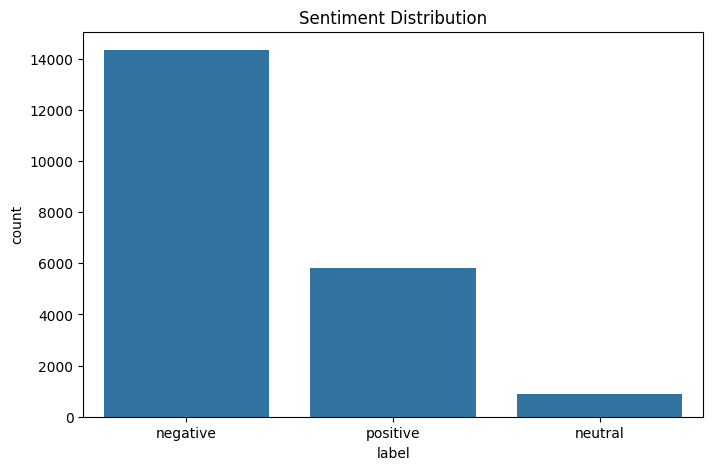

In [8]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="label"
)

plt.title("Sentiment Distribution")

plt.savefig(
    "sentiment_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# TEXT PREPROCESSING

In [9]:
stop_words = set(
    stopwords.words("english")
)

lemmatizer = WordNetLemmatizer()

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"www\S+", "", text)

    text = re.sub(r"\d+", "", text)

    text = text.translate(
        str.maketrans(
            "",
            "",
            string.punctuation
        )
    )

    tokens = nltk.word_tokenize(text)

    tokens = [

        lemmatizer.lemmatize(word)

        for word in tokens

        if word not in stop_words

    ]

    return " ".join(tokens)

print("Cleaning reviews...")

df["clean_review"] = df[
    "review"
].apply(clean_text)

Cleaning reviews...


# REVIEW LENGTH DISTRIBUTION

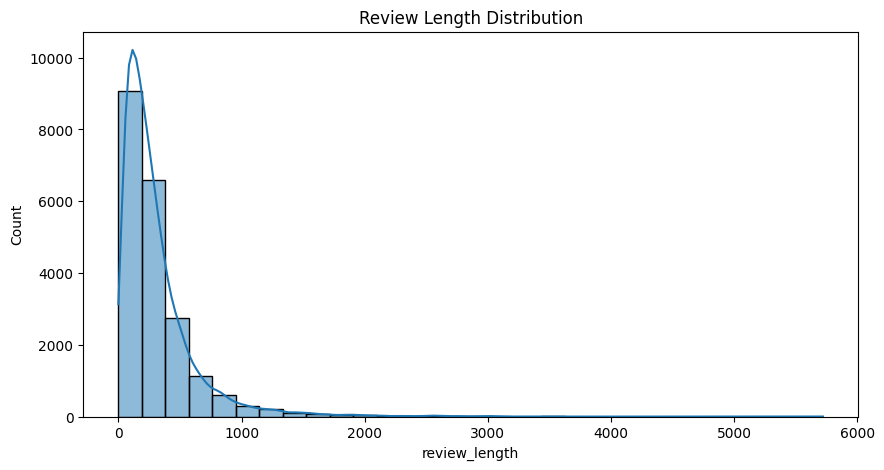

In [10]:
df["review_length"] = df[
    "clean_review"
].apply(len)

plt.figure(figsize=(10,5))

sns.histplot(
    df["review_length"],
    bins=30,
    kde=True
)

plt.title(
    "Review Length Distribution"
)

plt.savefig(
    "review_length_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# WORD CLOUD

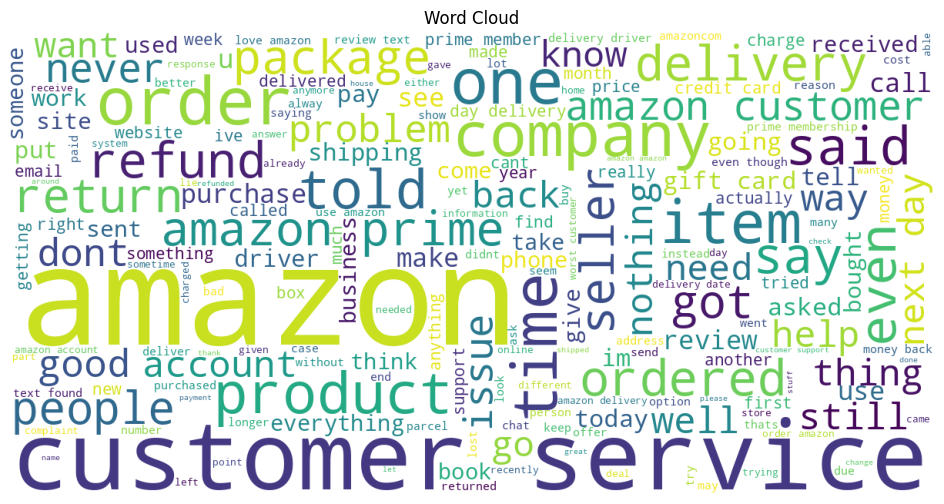

In [11]:
all_text = " ".join(
    df["clean_review"]
)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(all_text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Word Cloud")

plt.savefig(
    "wordcloud.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# TF-IDF

In [12]:
X = df["clean_review"]

y = df["label"]

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2)
)

X_tfidf = tfidf.fit_transform(X)

print(
    "TF-IDF Shape:",
    X_tfidf.shape
)


TF-IDF Shape: (21027, 10000)


# TRAIN TEST SPLIT

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# MODEL COMPARISON

In [22]:
models = {

    "Naive Bayes":
        MultinomialNB(),

    "Logistic Regression":
        LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            random_state=42
        ),

    "Linear SVM":
        LinearSVC(
            class_weight="balanced",
            random_state=42
        )
}

# BEST MODEL

In [15]:
best_name = max(
    results,
    key=results.get
)

best_model = models[
    best_name
]

print(
    "\nBest Model:",
    best_name
)


Best Model: Logistic Regression


# FINAL EVALUATION

In [23]:
y_pred = best_model.predict(
    X_test
)

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

    negative       0.92      0.98      0.95      2869
     neutral       0.43      0.02      0.03       177
    positive       0.91      0.88      0.89      1160

    accuracy                           0.91      4206
   macro avg       0.75      0.63      0.62      4206
weighted avg       0.89      0.91      0.89      4206



In [24]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(
    y_test,
    y_pred
)

balanced_acc = balanced_accuracy_score(
    y_test,
    y_pred
)

macro_f1 = f1_score(
    y_test,
    y_pred,
    average='macro'
)

print("="*50)
print("MODEL PERFORMANCE")
print("="*50)

print(f"Accuracy          : {accuracy:.4f}")
print(f"Balanced Accuracy : {balanced_acc:.4f}")
print(f"Macro F1 Score    : {macro_f1:.4f}")

MODEL PERFORMANCE
Accuracy          : 0.9137
Balanced Accuracy : 0.6255
Macro F1 Score    : 0.6243


# CONFUSION MATRIX

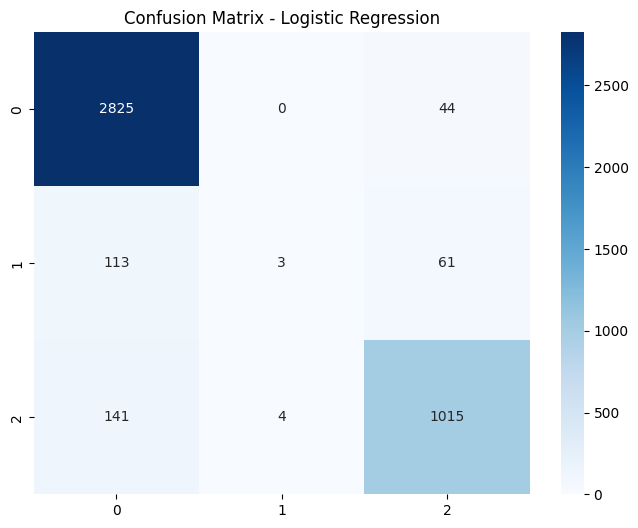

In [17]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    f"Confusion Matrix - {best_name}"
)

plt.savefig(
    "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# MODEL COMPARISON CHART

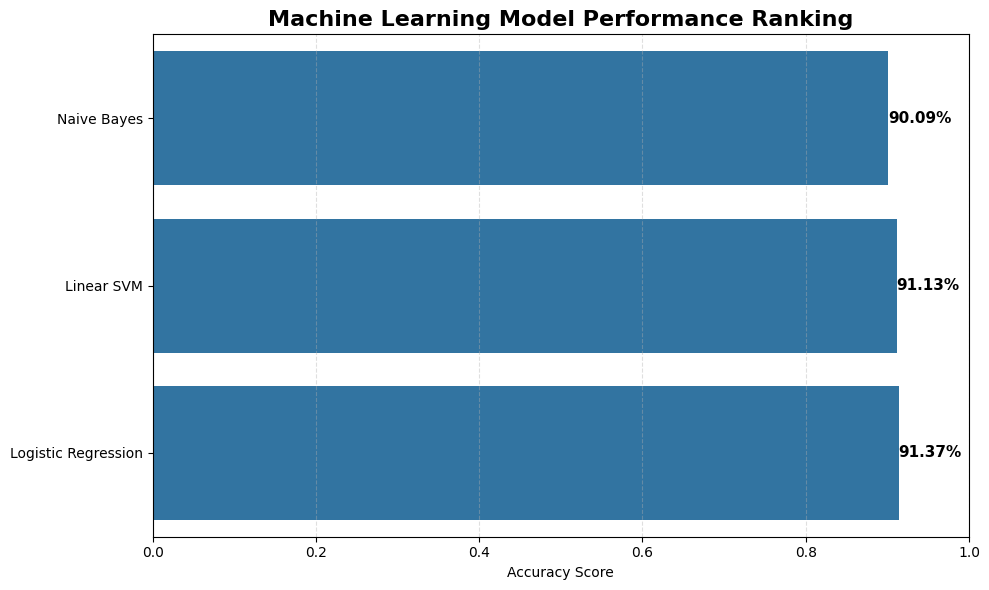

In [25]:
result_df = pd.DataFrame({
    "Model": list(results.keys()),
    "Accuracy": list(results.values())
})

result_df = result_df.sort_values(
    by="Accuracy",
    ascending=True
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=result_df,
    y="Model",
    x="Accuracy"
)

plt.title(
    "Machine Learning Model Performance Ranking",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Accuracy Score")
plt.ylabel("")

plt.xlim(0, 1)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

for p in ax.patches:

    width = p.get_width()

    ax.annotate(
        f"{width:.2%}",
        (
            width,
            p.get_y() + p.get_height()/2
        ),
        ha="left",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()

plt.savefig(
    "model_ranking.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# TOP WORDS

In [26]:
feature_names = np.array(
    tfidf.get_feature_names_out()
)

if hasattr(best_model, "coef_"):

    coef = best_model.coef_

    classes = best_model.classes_

    for i, label in enumerate(classes):

        print("\n")
        print("="*50)
        print(f"TOP WORDS FOR {label.upper()}")
        print("="*50)

        top_words = np.argsort(
            coef[i]
        )[-15:]

        print(
            feature_names[top_words]
        )



TOP WORDS FOR NEGATIVE
['cancel' 'disgusting' 'worse' 'awful' 'joke' 'money' 'lie' 'told' 'gone'
 'useless' 'account' 'poor' 'terrible' 'horrible' 'worst']


TOP WORDS FOR NEUTRAL
['overall' 'need' 'miss' 'delivery' 'slow' 'end' 'normally' 'like'
 'sometimes' 'ok' 'average' 'good' 'decent' 'okay' 'however']


TOP WORDS FOR POSITIVE
['good' 'problem' 'awesome' 'perfect' 'fantastic' 'everything' 'quickly'
 'fast' 'easy' 'amazing' 'always' 'love' 'best' 'excellent' 'great']


In [19]:
joblib.dump(
    best_model,
    "sentiment_model.pkl"
)

joblib.dump(
    tfidf,
    "tfidf_vectorizer.pkl"
)

print(
    "\nModel Saved Successfully"
)


Model Saved Successfully


In [28]:
print("\n")
print("="*60)
print("BUSINESS INSIGHTS")
print("="*60)

sentiment_stats = (
    df["label"]
    .value_counts(normalize=True)
    *100
)

print(sentiment_stats)

dominant_sentiment = sentiment_stats.idxmax()

print(f"\nDominant Sentiment : {dominant_sentiment}")

if dominant_sentiment == "positive":

    print("""
Customers generally express satisfaction with products.
The company should maintain product quality and customer service standards.
""")

elif dominant_sentiment == "negative":

    print("""
Negative feedback dominates customer perception.
Immediate investigation into product quality and customer experience is recommended.
""")

else:

    print("""
Customer opinions are mostly neutral.
Additional marketing and product differentiation strategies may improve customer satisfaction.
""")



BUSINESS INSIGHTS
label
negative    68.212298
positive    27.588339
neutral      4.199363
Name: proportion, dtype: float64

Dominant Sentiment : negative

Negative feedback dominates customer perception.
Immediate investigation into product quality and customer experience is recommended.

